# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie

De soortelijke warmte van een stof is de hoeveelheid warmte-energie die nodig is om de temperatuur van 1 kilogram van die stof met 1 graad Kelvin te verhogen. Voor water is deze waarde ongeveer 4184 J/(kg·K). De formule voor de soortelijke warmte c is:
$$
    Q = m*c*\Delta T
$$
waarbij:
- Q = de warmte-energie (J)
- m = de massa van de stof (kg)
- c = de soortelijke warmte (J/(kg·K))
- $\Delta$ T = het temperatuursverschil (K)



Door deze formule te herschrijven krijg je een formule om de soortelijke warmte te berekenen:
$$
    c = \frac{Q}{m \Delta T}
$$


De Q kan bij een elektrisch verwarmingselement worden berekend met het elektrisch vermogen P en de verwarmingstijd t:
$$
    Q = P * t
$$
Dit ingevult in de formule voor soortelijke warmte geeft:
$$
c = \frac{pt}{m \Delta T}
$$
Door de temperatuur van het water over tijd te meten, kunnen we de soortelijke warmte van water bepalen en het effect van de hoge buffercapaciteit van water waarnemen.


# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
```{exercise}
1. Beschrijf de procedure die nodig is om de soortelijke warmte van water te bepalen.
2. Geef jouw beschrijving van de procedure aan een ander team, zij verzamelen voor jou de data op basis van de gegevens.
3. Voer het experiment van een ander team uit op basis van hun beschrijving.
4. Analyseer de data die het andere groepje voor jou heeft verzameld.
```

procedure:
- Voeg 400 ml water toe aan de beker. 
- Zet de thermometer in het water en meet de begintemperatuur.
- Zet de magneetdingdraaier aan op 6.
- Sluit t het elektrisch verwarmingselement aan op de voedingsbron, zet in het water, en zet het voltage op 10 volt en 1 amp.
- Meet elke 15 seconde de temperatuur tot 10 min


## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
Geef kort de data-analysemethode weer.

# Resultaten


Soortelijke warmte c = 4540.8 ± 35.3 J/(kg·K)
waarde komt niet overeen


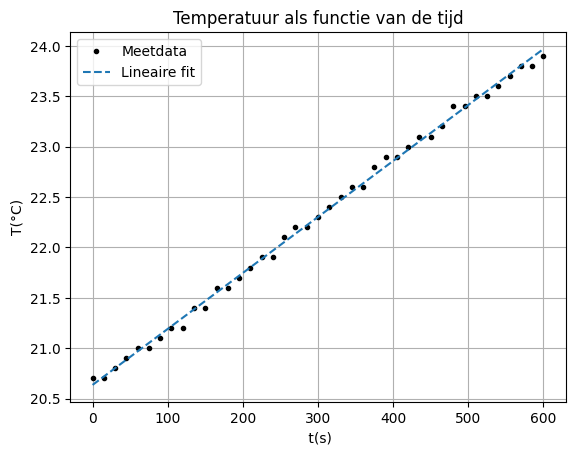

In [6]:
# Hier de data en de analyse
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

temp = np.array([20.7,20.7,20.8,20.9,21.0,21.0,21.1,21.2,21.2,21.4,21.4,21.6,21.6,21.7,21.8,21.9,21.9,22.1,22.2,22.2,22.3,22.4,22.5,22.6,22.6,
                 22.8,22.9,22.9,23.0,23.1,23.1,23.2,23.4,23.4,23.5,23.5,23.6,23.7,23.8,23.8,23.9])
tijd = np.arange(0,601,15)

U = 9.99 #V
I = 1.01 #A
vermogen = 10.09 #Watt
t= 600 #s
Q= vermogen*t
#print(Q)
#Q=6054.0
#massa water 400 ml = 400 g
m= 0.4 #kg

#soortelijke warmte formule is Q= m*c*deltaT, waar c de soortelijke warmte is en Q de benodigde warmte
# c= Q/m*deltaT


#c= soortelijke_warmte(Q,m, 23.9-20.7)
#print(c)
    
def model(t, a, b):
    return a * t + b

#curve fit
popt, cov = curve_fit(model, tijd, temp)
std_a = np.sqrt(cov[0,0])  # standaardfout van helling

# Berekening soortelijke warmte direct uit params
c = vermogen / (m * popt[0])
c_err = (vermogen / (m * popt[0]**2)) * std_a

# Resultaat
print(f"Soortelijke warmte c = {c:.1f} ± {c_err:.1f} J/(kg·K)")



# Soortelijke warmte
# a = dT/dt = P / (m*c)  →  c = P / (m*a)

#strijdigheidsanalyse
if abs(4184 - c)> np.sqrt(c_err**2):
    print('waarde komt niet overeen')
else :
    print('waarde komt wel overeen')

# Grafiek
plt.figure()
plt.plot(tijd, temp, "k.", label="Meetdata")
plt.plot(tijd, model(tijd, *popt), '--', label="Lineaire fit")
plt.xlabel(" t(s)")
plt.ylabel("T(°C)")
plt.title("Temperatuur als functie van de tijd")
plt.legend() 
plt.grid(True)
plt.savefig("soortelijke_warmte_van_water.png", dpi=450)
plt.show()


In [ ]:
# Sla figuren op met  
# 
# plt.savefig("figures/naam.png", dpi=450)



# Discussie en conclusie

De proef geeft een waarde voor c uit de curve-fit van 4.54 +- 0.04 *10^3 J/(kg*K), wat ver van de bekende waarde c ligt, zoals blijkt uit de strijdigheidsanalyse. Dit is waarschijnlijk te verklagen door systematische fouten, waarbij de temperatuur niet precies elke 15 s is gemeten. Andere redenen voor de systematische fout zouden bijvoorbeeld kunnen zijn dat warmte verloren is gegaan, terwijl vanuit werd gegaan dat alle elektrische energie in het water terechtkomt, terwijl in de praktijk een deel verloren gaat aan de omgeving, waardoor de berekende soortelijke warmte te hoog wordt.

Hoewel het experiment een algemene schatting kan maken over de soortelijke warmte van water, kan je uit de resultaten zien dat de proef geen goede manier is om een preciese waarde te krijgen voor c. Voor nauwkeurigere resultaten in een vervolgonderzoek is het beter om te voorkomen dat er warmteverlies is en om nauwkeuriger meetapperatuur te gebruiken.